Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


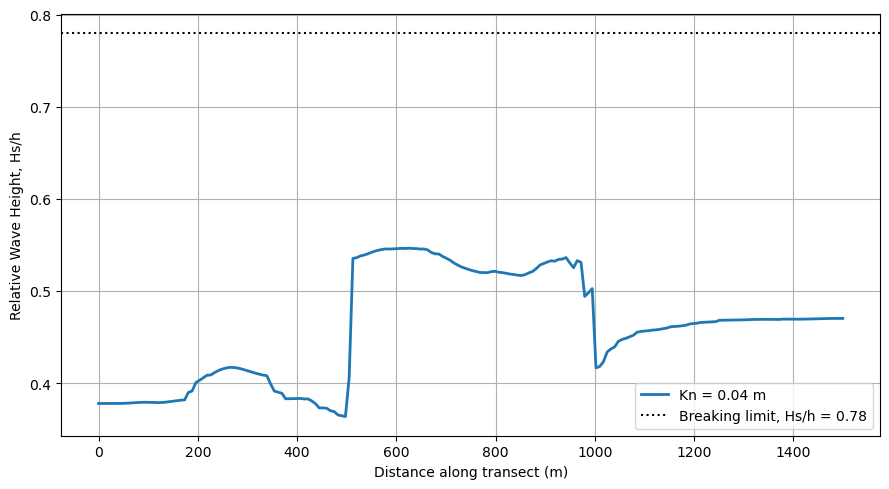

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

#dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

#dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Change this path if your Kn = 0.30 m file is different
#dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
# hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
# hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
# hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
# ratio_01  = hs_01  / depth_profile
# ratio_02  = hs_02  / depth_profile
# ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
# print("Selected timestep for Kn = 0.10 m:", time_01)
# print("Selected timestep for Kn = 0.20 m:", time_02)
# print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
# plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
# plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
# plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
# plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


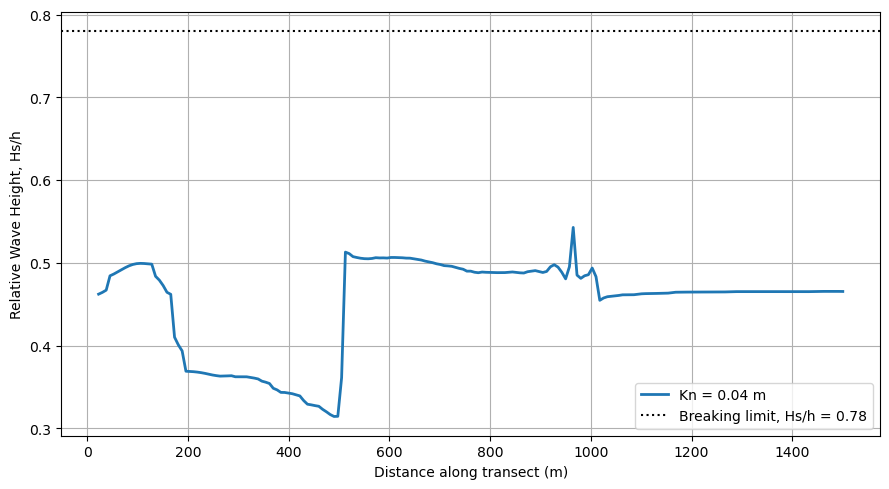

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

#dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

#dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Change this path if your Kn = 0.30 m file is different
#dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
# hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
# hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
# hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
# ratio_01  = hs_01  / depth_profile
# ratio_02  = hs_02  / depth_profile
# ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
# print("Selected timestep for Kn = 0.10 m:", time_01)
# print("Selected timestep for Kn = 0.20 m:", time_02)
# print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
# plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
# plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
# plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
# plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


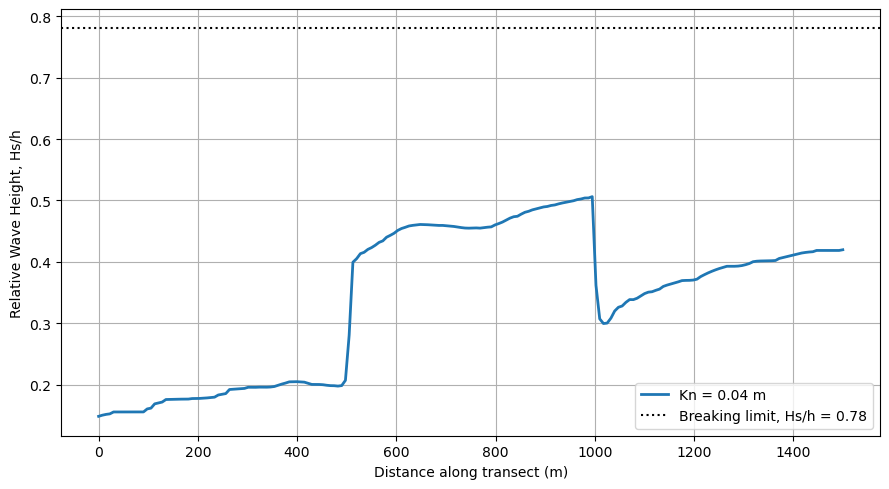

In [3]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

#dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

#dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Change this path if your Kn = 0.30 m file is different
#dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
# hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
# hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
# hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
# ratio_01  = hs_01  / depth_profile
# ratio_02  = hs_02  / depth_profile
# ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
# print("Selected timestep for Kn = 0.10 m:", time_01)
# print("Selected timestep for Kn = 0.20 m:", time_02)
# print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
# plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
# plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
# plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
# plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()